## Building and AI Music Composer
### 1. Data Preprocessing
### 2. Architecture (model building)
### 3. Training
### 4. Inference (generation)


## Library Installitation and Setup

In [ ]:
! pip install comet_ml > /dev/null 2>&1
import comet_ml
# TODO: ENTER YOUR API KEY HERE!! instructions above
COMET_API_KEY = "MtZTLZDoSjjQBCZ5xNESjjtOX"

# Import PyTorch and other relevant libraries
import torch
import torch.nn as nn
import torch.optim as optim

# Download and import the MIT Introduction to Deep Learning package
!pip install mitdeeplearning --quiet
import mitdeeplearning as mdl

# Import all remaining packages
import numpy as np
import os
import time
import functools
from IPython import display as ipythondisplay
from tqdm import tqdm
from scipy.io.wavfile import write
!apt-get install abcmidi timidity > /dev/null 2>&1


# Check that we are using a GPU, if not switch runtimes
#   using Runtime > Change Runtime Type > GPU
assert torch.cuda.is_available(), "Please enable GPU from runtime settings"
assert COMET_API_KEY != "", "Please insert your Comet API Key"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 73.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.9/155.9 kB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Dataset

In [ ]:
# Download the dataset
songs = mdl.lab1.load_training_data()

# Print one of the songs to inspect it in greater detail!
example_song = songs[0]
print("\nExample song: ")
print(example_song)

Found 817 songs in text

Example song: 
X:1
T:Alexander's
Z: id:dc-hornpipe-1
M:C|
L:1/8
K:D Major
(3ABc|dAFA DFAd|fdcd FAdf|gfge fefd|(3efe (3dcB A2 (3ABc|!
dAFA DFAd|fdcd FAdf|gfge fefd|(3efe dc d2:|!
AG|FAdA FAdA|GBdB GBdB|Acec Acec|dfaf gecA|!
FAdA FAdA|GBdB GBdB|Aceg fefd|(3efe dc d2:|!


In [ ]:
type(songs)

list

In [ ]:
print(songs[1])

X:2
T:An Buachaill Dreoite
Z: id:dc-hornpipe-2
M:C|
L:1/8
K:G Major
GF|DGGB d2GB|d2GF Gc (3AGF|DGGB d2GB|dBcA F2GF|!
DGGB d2GF|DGGF G2Ge|fgaf gbag|fdcA G2:|!
GA|B2BG c2cA|d2GF G2GA|B2BG c2cA|d2DE F2GA|!
B2BG c2cA|d^cde f2 (3def|g2gf gbag|fdcA G2:|!


In [ ]:
songs[0]

"X:1\nT:Alexander's\nZ: id:dc-hornpipe-1\nM:C|\nL:1/8\nK:D Major\n(3ABc|dAFA DFAd|fdcd FAdf|gfge fefd|(3efe (3dcB A2 (3ABc|!\ndAFA DFAd|fdcd FAdf|gfge fefd|(3efe dc d2:|!\nAG|FAdA FAdA|GBdB GBdB|Acec Acec|dfaf gecA|!\nFAdA FAdA|GBdB GBdB|Aceg fefd|(3efe dc d2:|!"

In [ ]:
joined_songs = "\n\n".join(songs) # to remove all the space

In [ ]:
joined_songs[7]

'l'

In [ ]:
## building vocab
vocab = sorted(set(joined_songs))
print(f"length of vocab:{vocab.__len__()}")

length of vocab:83


In [ ]:
for i , u in enumerate(vocab):
  print(i,u)
  break

0 



In [ ]:
char2idx = {u:i for i,u in enumerate(vocab)} # an mapping

In [ ]:
char2idx

{'\n': 0,
 ' ': 1,
 '!': 2,
 '"': 3,
 '#': 4,
 "'": 5,
 '(': 6,
 ')': 7,
 ',': 8,
 '-': 9,
 '.': 10,
 '/': 11,
 '0': 12,
 '1': 13,
 '2': 14,
 '3': 15,
 '4': 16,
 '5': 17,
 '6': 18,
 '7': 19,
 '8': 20,
 '9': 21,
 ':': 22,
 '<': 23,
 '=': 24,
 '>': 25,
 'A': 26,
 'B': 27,
 'C': 28,
 'D': 29,
 'E': 30,
 'F': 31,
 'G': 32,
 'H': 33,
 'I': 34,
 'J': 35,
 'K': 36,
 'L': 37,
 'M': 38,
 'N': 39,
 'O': 40,
 'P': 41,
 'Q': 42,
 'R': 43,
 'S': 44,
 'T': 45,
 'U': 46,
 'V': 47,
 'W': 48,
 'X': 49,
 'Y': 50,
 'Z': 51,
 '[': 52,
 ']': 53,
 '^': 54,
 '_': 55,
 'a': 56,
 'b': 57,
 'c': 58,
 'd': 59,
 'e': 60,
 'f': 61,
 'g': 62,
 'h': 63,
 'i': 64,
 'j': 65,
 'k': 66,
 'l': 67,
 'm': 68,
 'n': 69,
 'o': 70,
 'p': 71,
 'q': 72,
 'r': 73,
 's': 74,
 't': 75,
 'u': 76,
 'v': 77,
 'w': 78,
 'x': 79,
 'y': 80,
 'z': 81,
 '|': 82}

In [ ]:
idx2char = np.array(vocab)
idx2char

array(['\n', ' ', '!', '"', '#', "'", '(', ')', ',', '-', '.', '/', '0',
       '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', '<', '=', '>',
       'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
       'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
       '[', ']', '^', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i',
       'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v',
       'w', 'x', 'y', 'z', '|'], dtype='<U1')

In [ ]:
print('{')
for char, _ in zip(char2idx, range(20)):
    print('  {:4s}: {:3d},'.format(repr(char), char2idx[char]))
print('  ...\n}')

{
  '\n':   0,
  ' ' :   1,
  '!' :   2,
  '"' :   3,
  '#' :   4,
  "'" :   5,
  '(' :   6,
  ')' :   7,
  ',' :   8,
  '-' :   9,
  '.' :  10,
  '/' :  11,
  '0' :  12,
  '1' :  13,
  '2' :  14,
  '3' :  15,
  '4' :  16,
  '5' :  17,
  '6' :  18,
  '7' :  19,
  ...
}


In [ ]:
## vecotorize the string
def vectorize(string_):
  vectorized_array = np.array([char2idx[char] for char in string_])
  return vectorized_array

In [ ]:
vectorized = vectorize(joined_songs)
vectorized

array([49, 22, 13, ..., 22, 82,  2])

In [ ]:
print ('{} ---- characters mapped to int ----> {}'.format(repr(joined_songs[:10]), vectorized[:10]))
# check that vectorized_songs is a numpy array
assert isinstance(vectorized, np.ndarray), "returned result should be a numpy array"

'X:1\nT:Alex' ---- characters mapped to int ----> [49 22 13  0 45 22 26 67 60 79]


In [ ]:
def get_batch(songs_,batch_size,seq_len):
  n = songs_.shape[0] - 1 # the train sample final end
  idx = np.random.choice(n - seq_len,batch_size) # to generate and batch of random string
  input_batch = [songs_[i:i+seq_len] for i in idx]
  output_batch = [songs_[i+1:i+seq_len+1] for i in idx]
  x_batch = torch.tensor(input_batch,dtype=torch.long)
  y_batch = torch.tensor(output_batch,dtype=torch.long)
  return x_batch , y_batch

In [ ]:
x_batch, y_batch = get_batch(vectorized, 2,10)
assert x_batch.shape == (2, 10), "x_batch shape is incorrect"
assert y_batch.shape == (2, 10), "y_batch shape is incorrect"
print("Batch function works correctly!")

Batch function works correctly!


In [ ]:
x_batch, y_batch = get_batch(vectorized, seq_len=5, batch_size=1)

for i, (input_idx, target_idx) in enumerate(zip(x_batch[0], y_batch[0])):
    print("Step {:3d}".format(i))
    print("  input: {} ({:s})".format(input_idx, repr(idx2char[input_idx.item()])))
    print("  expected output: {} ({:s})".format(target_idx, repr(idx2char[target_idx.item()])))

Step   0
  input: 1 (np.str_(' '))
  expected output: 56 (np.str_('a'))
Step   1
  input: 56 (np.str_('a'))
  expected output: 57 (np.str_('b'))
Step   2
  input: 57 (np.str_('b'))
  expected output: 56 (np.str_('a'))
Step   3
  input: 56 (np.str_('a'))
  expected output: 82 (np.str_('|'))
Step   4
  input: 82 (np.str_('|'))
  expected output: 62 (np.str_('g'))


In [ ]:
x_batch , y_batch

(tensor([[ 1, 56, 57, 56, 82]]), tensor([[56, 57, 56, 82, 62]]))

In [ ]:
len(np.random.choice(vectorized.shape[0] - 1 , 32))

32

In [ ]:
[vectorized[i:i+10] for i in (np.random.choice(vectorized.shape[0] - 1 , 32))]

[array([58,  1, 59, 15, 22, 82,  2,  0, 61, 56]),
 array([60, 61, 59, 82,  6, 15, 60, 61, 60,  1]),
 array([82, 59, 27, 26, 32,  1, 31, 29, 29, 22]),
 array([14,  1, 62, 60, 59, 27, 82, 26, 14, 31]),
 array([59, 27, 26, 31,  1, 30, 15, 31, 82,  2]),
 array([63, 60,  1, 28, 63, 60, 73, 73, 80,  1]),
 array([58, 26,  1, 27, 32, 32, 58, 82, 26, 27]),
 array([31,  1, 32, 31, 30, 22, 82,  2,  0, 29]),
 array([64, 59, 22, 59, 58,  9, 63, 70, 73, 69]),
 array([56, 61, 82, 62, 61, 62, 56,  1, 57, 60]),
 array([60, 61,  1, 62, 14, 61, 82, 60, 56, 56]),
 array([32, 27, 59,  1, 60, 62, 60, 82, 59, 27]),
 array([30, 82,  2,  0, 31, 30,  1, 31, 14,  1]),
 array([31, 30, 29, 82,  2,  0, 32, 14, 27, 59]),
 array([59, 54, 58,  1, 59, 14, 22, 82,  2,  0]),
 array([61, 62, 56, 62,  1, 61, 59, 59, 62, 82]),
 array([14, 82, 58, 14,  1, 26, 14,  1, 32, 14]),
 array([ 0, 51, 22,  1, 64, 59, 22, 59, 58,  9]),
 array([ 1, 56, 62, 62, 14, 82, 59, 62, 62, 14]),
 array([27, 82, 26, 58, 27, 26,  1, 32, 30, 29]),


In [ ]:
[vectorized[i+1:i+10+1] for i in (np.random.choice(vectorized.shape[0] - 1 , 32))]

[array([15, 58, 27, 26, 82, 32, 26, 31, 14,  1]),
 array([59, 58,  9, 74, 67, 64, 59, 60,  9, 14]),
 array([59, 14, 60,  1, 61, 14, 56, 82, 62, 14]),
 array([31,  1, 32, 31, 32, 27, 82, 26, 32, 31]),
 array([31, 14,  1, 59, 61, 60, 59, 82, 52, 13]),
 array([ 0, 49, 22, 16, 13,  0, 45, 22, 31, 73]),
 array([ 1, 57, 62, 62, 14, 82, 56, 62, 61, 56]),
 array([ 1, 58, 27, 82, 26, 14,  1, 59, 14,  1]),
 array([59, 82, 60, 32, 58, 60,  1, 59, 60, 61]),
 array([61, 59, 59, 82, 56, 59, 59,  1, 61, 59]),
 array([ 9, 20, 13,  0, 38, 22, 18, 11, 20,  0]),
 array([29, 82, 30, 26, 32,  1, 30, 29, 30, 82]),
 array([ 1, 60, 62, 59, 27,  1, 32, 26, 27, 59]),
 array([56, 61, 61, 14, 82, 62, 61, 60, 61,  1]),
 array([64, 62,  9, 13, 16, 18,  0, 38, 22, 18]),
 array([ 2,  0, 32, 27, 59, 62,  1, 60, 62, 59]),
 array([26, 58, 22, 82,  2,  0, 27, 15, 26,  1]),
 array([15,  0, 38, 22, 28,  0, 37, 22, 13, 11]),
 array([29, 30, 82, 31, 14, 29, 14,  1, 29, 14]),
 array([22, 13, 18, 20,  0, 45, 22, 48, 63, 60]),


In [ ]:
class LSTM_MODEL(nn.Module):
  def __init__(self,vocab_size,embedding_dim,hidden_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.embedding = nn.Embedding(vocab_size,embedding_dim)
    self.lstm = nn.LSTM(embedding_dim,hidden_size,num_layers=1,batch_first=True)
    self.linear_fc = nn.Linear(hidden_size,vocab_size)
  def init_hidden(self, batch_size, device):
        # Initialize hidden state and cell state with zeros
      return (torch.zeros(1, batch_size, self.hidden_size).to(device),
                torch.zeros(1, batch_size, self.hidden_size).to(device))

  def forward(self, x, state=None, return_state=False):
      x = self.embedding(x)

      if state is None:
          state = self.init_hidden(x.size(0), x.device)
      out, state = self.lstm(x, state)

      out = self.linear_fc(out)
      return out if not return_state else (out, state)

In [ ]:
# Instantiate the model! Build a simple model with default hyperparameters. You
#     will get the chance to change these later.
vocab_size = len(vocab)
embedding_dim = 256
hidden_size = 1024
batch_size = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTM_MODEL(vocab_size, embedding_dim, hidden_size).to(device)

# print out a summary of the model
print(model)

LSTM_MODEL(
  (embedding): Embedding(83, 256)
  (lstm): LSTM(256, 1024, batch_first=True)
  (linear_fc): Linear(in_features=1024, out_features=83, bias=True)
)


In [ ]:
# Test the model with some sample data
x, y = get_batch(vectorized,batch_size=32,seq_len=100)
x = x.to(device)
y = y.to(device)
print(x.shape,y.shape)
pred = model(x)
print("Input shape:      ", x.shape, " # (batch_size, sequence_length)")
print("Prediction shape: ", pred.shape, "# (batch_size, sequence_length, vocab_size)")

torch.Size([32, 100]) torch.Size([32, 100])
Input shape:       torch.Size([32, 100])  # (batch_size, sequence_length)
Prediction shape:  torch.Size([32, 100, 83]) # (batch_size, sequence_length, vocab_size)


In [ ]:
pred[0].shape

torch.Size([100, 83])

In [ ]:
sampled_indices = torch.multinomial(torch.softmax(pred[0], dim=-1), num_samples=1)
sampled_indices = sampled_indices.squeeze(-1).cpu().numpy()
sampled_indices
# for randomness i.e generatation different music notes here multinomial is added to randomly sample any point from the data

array([58,  6, 37, 15, 39, 34,  4, 31, 55, 47, 76, 15, 60, 23,  2, 44, 30,
       26, 24, 65, 61, 81, 71, 73, 22, 53, 34, 39, 71, 65, 16, 26, 25, 60,
       61, 11, 60, 15, 51, 55, 69, 10,  1, 70, 39, 41, 32, 18, 31, 76, 37,
       21, 43, 21, 50, 78, 42, 63, 40, 19, 65, 49, 14, 33, 12, 70,  7, 39,
       24, 53,  1, 22,  2, 11,  1, 69, 66, 80, 67, 16, 69,  5, 77, 35, 47,
       67, 38, 29, 22,  9, 60, 40, 40, 67, 17, 69, 56, 20, 53, 47])

In [ ]:
print("Input: \n", repr("".join(idx2char[x[0].cpu()])))
print()
print("Next Char Predictions: \n", repr("".join(idx2char[sampled_indices])))

Input: 
 'dfag|fdec dBAG|FGEF D2:|!\nfg|afdg bgeg|fdec dcBc|Addc defg|a2^gb a2f=g|!\nagfa gfeg|fdec dfag|fdec dB'

Next Char Predictions: 
 "c(L3NI#F_Vu3e<!SEA=jfzpr:]INpj4A>ef/e3Z_n. oNPG6FuL9R9YwQhO7jX2H0o)N=] :!/ nkyl4n'vJVlMD:-eOOl5na8]V"


In [ ]:
### Defining the loss function ###

# '''TODO: define the compute_loss function to compute and return the loss between
#     the true labels and predictions (logits). '''
cross_entropy = nn.CrossEntropyLoss() # instantiates the function
def compute_loss(labels, logits):
    """
    Inputs:
      labels: (batch_size, sequence_length)
      logits: (batch_size, sequence_length, vocab_size)

    Output:
      loss: scalar cross entropy loss over the batch and sequence length
    """

    # Batch the labels so that the shape of the labels should be (B * L,)
    batched_labels = labels.view(-1)

    ''' TODO: Batch the logits so that the shape of the logits should be (B * L, V) '''
    # We reshape logits to combine the batch and sequence dimensions
    batched_logits = logits.view(-1, logits.size(-1))

    '''TODO: Compute the cross-entropy loss using the batched next characters and predictions'''
    loss = cross_entropy(batched_logits, batched_labels)

    return loss

In [ ]:
### compute the loss on the predictions from the untrained model from earlier. ###
y.shape  # (batch_size, sequence_length)
pred.shape  # (batch_size, sequence_length, vocab_size)

'''TODO: compute the loss using the true next characters from the example batch
    and the predictions from the untrained model several cells above'''
example_batch_loss = compute_loss(y,pred) # TODO

print(f"Prediction shape: {pred.shape} # (batch_size, sequence_length, vocab_size)")
print(f"scalar_loss:      {example_batch_loss.mean().item()}")

Prediction shape: torch.Size([32, 100, 83]) # (batch_size, sequence_length, vocab_size)
scalar_loss:      4.425063610076904


In [ ]:
y.shape
y.view(-1).shape # 3200
pred.view(-1,pred.size(-1)).shape

torch.Size([3200, 83])

In [ ]:
pred.shape

torch.Size([32, 100, 83])

In [ ]:
### Hyperparameter setting and optimization ###

vocab_size = len(vocab)

# Model parameters:
params = dict(
  num_training_iterations = 3000,  # Increase this to train longer
  batch_size = 8,  # Experiment between 1 and 64
  seq_length = 100,  # Experiment between 50 and 500
  learning_rate = 5e-3,  # Experiment between 1e-5 and 1e-1
  embedding_dim = 256,
  hidden_size = 1024,  # Experiment between 1 and 2048
)

# Checkpoint location:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "my_ckpt")
os.makedirs(checkpoint_dir, exist_ok=True)

In [ ]:
### Create a Comet experiment to track our training run ###

def create_experiment():
  # end any prior experiments
  if 'experiment' in locals():
    experiment.end()

  # initiate the comet experiment for tracking
  experiment = comet_ml.Experiment(
                  api_key=COMET_API_KEY,
                  project_name="6S191_Lab1_Part2")
  # log our hyperparameters, defined above, to the experiment
  for param, value in params.items():
    experiment.log_parameter(param, value)
  experiment.flush()

  return experiment

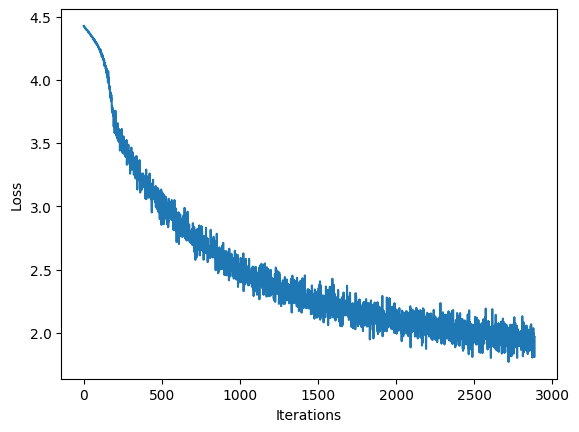

100%|██████████| 3000/3000 [00:40<00:00, 74.60it/s]
COMET INFO: Uploading 251 metrics, params and output messages


True

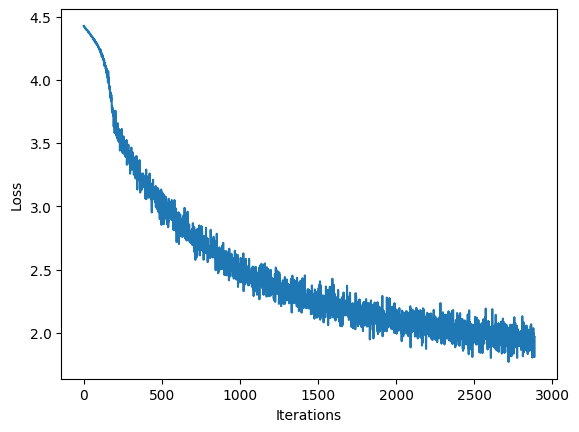

In [ ]:
### Define optimizer and training operation ###

'''TODO: instantiate a new LSTMModel model for training using the hyperparameters
    created above.'''
model = LSTM_MODEL(vocab_size,embedding_dim,hidden_size)

# Move the model to the GPU
model.to(device)

'''TODO: instantiate an optimizer with its learning rate.
  Checkout the PyTorch website for a list of supported optimizers.
  https://pytorch.org/docs/stable/optim.html
  Try using the Adam optimizer to start.'''
optimizer = torch.optim.Adam(model.parameters(),lr=1e-5)

def train_step(x, y):
  # Set the model's mode to train
  model.train()

  # Zero gradients for every step
  optimizer.zero_grad()

  # Forward pass
  '''TODO: feed the current input into the model and generate predictions'''
  y_hat = model(x)

  # Compute the loss
  '''TODO: compute the loss!'''
  loss = compute_loss(y,y_hat)
  loss.backward()
  optimizer.step()
  # Backward pass
  '''TODO: complete the gradient computation and update step.
    Remember that in PyTorch there are two steps to the training loop:
    1. Backpropagate the loss
    2. Update the model parameters using the optimizer
  '''
  '''TODO'''

  return loss

##################
# Begin training!#
##################

history = []
plotter = mdl.util.PeriodicPlotter(sec=2, xlabel='Iterations', ylabel='Loss')
experiment = create_experiment()

if hasattr(tqdm, '_instances'): tqdm._instances.clear() # clear if it exists
for iter in tqdm(range(params["num_training_iterations"])):

    # Grab a batch and propagate it through the network
    x_batch, y_batch = get_batch(vectorized, params["seq_length"], params["batch_size"])

    # Convert numpy arrays to PyTorch tensors
    x_batch = torch.tensor(x_batch, dtype=torch.long).to(device)
    y_batch = torch.tensor(y_batch, dtype=torch.long).to(device)

    # Take a train step
    loss = train_step(x_batch, y_batch)

    # Log the loss to the Comet interface
    experiment.log_metric("loss", loss.item(), step=iter)

    # Update the progress bar and visualize within notebook
    history.append(loss.item())
    plotter.plot(history)

    # Save model checkpoint
    if iter % 100 == 0:
        torch.save(model.state_dict(), checkpoint_prefix)

# Save the final trained model
torch.save(model.state_dict(), checkpoint_prefix)
experiment.flush()

In [ ]:
### Prediction of a generated song ###

def generate_text(model, start_string, generation_length=1000):
  # Evaluation step (generating ABC text using the learned RNN model)

  model.eval() # Set model to evaluation mode

  '''TODO: convert the start string to numbers (vectorize)'''
  # We use the vectorize function we defined earlier to turn the string into an array of numbers
  input_idx = vectorize(start_string)
  input_idx = torch.tensor([input_idx], dtype=torch.long).to(device)

  # Initialize the hidden state
  state = model.init_hidden(input_idx.size(0), device)

  # Empty string to store our results
  text_generated = []
  tqdm._instances.clear()

  for i in tqdm(range(generation_length)):
    '''TODO: evaluate the inputs and generate the next character predictions'''
    # Pass the current input_idx and the previous state into the model
    predictions, state = model(input_idx, state, return_state=True)

    # Remove the batch dimension
    # predictions shape becomes (seq_len, vocab_size)
    predictions = predictions.squeeze(0)

    '''TODO: use a multinomial distribution to sample over the probabilities'''
    # We take the prediction for the VERY LAST character in the sequence
    prediction = predictions[-1:]
    # Convert to probabilities and sample the next character index
    input_idx = torch.multinomial(torch.softmax(prediction, dim=-1), num_samples=1)

    '''TODO: add the predicted character to the generated text!'''
    # Convert the predicted index back to a character and add it to our list
    predicted_char = idx2char[input_idx.item()]
    text_generated.append(predicted_char)

  return (start_string + ''.join(text_generated))

In [ ]:
# Define the start string (the 'seed') for the model
start_string = "X:1\n"

# Call the function you just completed
generated_text = generate_text(model, start_string, generation_length=1000)

# Print a preview of what the AI composed
print(generated_text)

100%|██████████| 1000/1000 [00:00<00:00, 1592.88it/s]

X:1
T:8
T:Majoor
BD DD=uoridedc-4Sns9Bcde-^
Major
|AABc c4Bc|BAG ,3fre|a2g2 c2:|c|cee fdef|g2B2 G2B|d2 GBd ABc|dBA dgd|BdB c2B|ABc A3F|ccAG A2Bl|!
A2de dBc BGBG|EAAG fGGF||!
AAFA FABA|^cBdd AG D|G2A2 AG2:|!

X|!

X:1e3
T:T^anianZysZ tits onVi: iohnsnolys
Z: iarna ntp-1GaF A2:|!

X:3
T:3o
T:fesele
Z: id:d idc:ii-ydic-its
Z: id:ksutpnhE P'slkiltkA ]as
Z: idel-ic-dee-195eg aoZ'7oL ohauink
Map
0 toraol ino pig-rk
Z: iinnpL MkxoyM's
L:1/6/8
L:1/8KKD G G2|GG|AGB D2DF|G,F,DE eBAGA|BGdB id:|C4
A/|!
ed A3 e|fgf dcBAB|c2de dBe|Bde efg2|afge f3g|g gfg|geef faefg|fag Bde|dBA BGBA|B2gd g2 fdg|agfd fdeedd|dcG G2:|!
f2|gag ed B]|!
|be cde|cABc cFA|G3:|!

X:29
T:26e intsn Bg ntWmeslTl-19u3
T:Mnc5ai ennt786
M:a
B2|A g|e2B dBGA||!
/de d2F /f|f2d edg|d^^gd2 dBF|![be dBde|f2BE cdBd|b2c f2e|!
d:dec|eABc d2BAf|e2gf gee|cB ced|]!
d2E G2E|GGE|G2AB Bcdf|e|faa g3(|c2be d2ef|ffef eF:|!
Ae2dcA dBdd|eAFA def^c|A2fe geg|fdef aggf|ggef dBG|AGF D2:G|EFDEE G/A2|AGA B2A|EFD e2A2|!
EG|Bc2 AGFA|!
EDE2 E2c|DAA|BE AFGF|!
G

In [ ]:
### Play back generated songs ###
generated_songs = mdl.lab1.extract_song_snippet(generated_text)

for i, song in enumerate(generated_songs):
  waveform = mdl.lab1.play_song(song)
  if waveform:
    print("Generated song", i)
    ipythondisplay.display(waveform)

Found 4 songs in text


In [ ]:
# Warning: This might just sound like static if the text is random!
mdl.lab1.play_song(generated_text)

In [ ]:
### Play back generated songs ###

# 1. Extract individual songs from the large block of generated text
generated_songs = mdl.lab1.extract_song_snippet(generated_text)

# 2. Loop through each found song and create an audio player
for i, song in enumerate(generated_songs):
    # Synthesize the waveform from the ABC text
    waveform = mdl.lab1.play_song(song)

    # If the song has valid syntax, display the play button
    if waveform:
        print(f"Generated song {i}:")
        ipythondisplay.display(waveform)

Found 4 songs in text


In [ ]:
def generate_text(model, start_string, generation_length=1000):
  model.eval() # Set model to evaluation mode

  # Vectorize the start string
  input_idx = vectorize(start_string)
  input_idx = torch.tensor([input_idx], dtype=torch.long).to(device)

  # Initialize the hidden state
  state = model.init_hidden(input_idx.size(0), device)

  text_generated = []
  tqdm._instances.clear()

  for i in tqdm(range(generation_length)):
    # Evaluate the inputs and generate the next character predictions
    predictions, state = model(input_idx, state, return_state=True)

    # Remove the batch dimension
    predictions = predictions.squeeze(0)

    # Use a multinomial distribution to sample over the probabilities
    # We take ONLY the last prediction in the sequence
    prediction = predictions[-1:]

    # Sample the index
    sampled_idx = torch.multinomial(torch.softmax(prediction, dim=-1), num_samples=1)

    # Add the predicted character to the list
    predicted_char = idx2char[sampled_idx.item()]
    text_generated.append(predicted_char)

    # Update input_idx for the next iteration
    input_idx = sampled_idx.unsqueeze(0)

  return (start_string + ''.join(text_generated))

In [ ]:
### Play back generated songs ###
generated_songs = mdl.lab1.extract_song_snippet(generated_text)

print(f"Found {len(generated_songs)} songs. Synthesizing audio...")

for i, song in enumerate(generated_songs):
    try:
        waveform = mdl.lab1.play_song(song)
        if waveform:
            print(f"Generated song {i}:")
            ipythondisplay.display(waveform)
        else:
            print(f"Song {i} has invalid music syntax and couldn't be played.")
    except Exception as e:
        print(f"Error playing song {i}: {e}")

Found 4 songs in text
Found 4 songs. Synthesizing audio...
Song 0 has invalid music syntax and couldn't be played.
Song 1 has invalid music syntax and couldn't be played.
Song 2 has invalid music syntax and couldn't be played.
Song 3 has invalid music syntax and couldn't be played.
